# 08 - Model evaluation: temporal and spatial blocking

Four models (XGBoost, random forest, SVR, LSTM) are tested on data they have not seen, in two ways:

- **Temporal blocking** - leave-one-year-out over 2019-2025. Each year is held out in turn and the
  model is trained on the other years.
- **Spatial blocking** - train on one tower, test on the other (EC-1/ASP -> EC-2/BAU and the reverse).
  The two fields have different crop rotations, so this tests transfer across management.

Set `FEATURE_SET` to `"6"` or `"3"` and run the notebook once for each. The six-feature run gives
Table 3 and Figs. 6 and 8 of the paper, the three-feature run gives Table 4 and Figs. 7 and 9.

In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVR
from tensorflow import keras
from xgboost import XGBRegressor

In [2]:
FEATURE_SET = "6"     # "6" or "3"

CONFIGS = {
    "6": {"features": ["10-d pcp", "EVI Median", "Rs", "Tmin", "RHmax", "Pcp"], "svr_C": 1},
    "3": {"features": ["10-d pcp", "EVI Median", "Rs"], "svr_C": 100},
}
FEATURES = CONFIGS[FEATURE_SET]["features"]
SVR_C = CONFIGS[FEATURE_SET]["svr_C"]     # C for the leave-one-year-out SVR
TARGET = "ETa"
MODELS = ["XGBoost", "RF", "SVR", "LSTM"]

DATA_DIR = Path("../data/model_input")
FIG_DIR = Path("../results/figures")
TABLE_DIR = Path("../results/tables")
tag = f"{FEATURE_SET}f"

ASP = pd.read_csv(DATA_DIR / "ASP_model_input.csv")    # EC-1
BAU = pd.read_csv(DATA_DIR / "BAU_model_input.csv")    # EC-2
df = pd.concat([ASP, BAU])
print("features:", FEATURES)

features: ['10-d pcp', 'EVI Median', 'Rs', 'Tmin', 'RHmax', 'Pcp']


In [3]:
def scores(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MBE": np.mean(y_pred - y_true),
    }


def set_seeds(seed=12):
    os.environ["PYTHONHASHSEED"] = "0"
    os.environ["TF_DETERMINISTIC_OPS"] = "1"
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

## Temporal blocking (leave one year out)

2018 is left out because only a few months of it overlap with the tower record.
XGBoost and RF handle missing inputs natively and use all rows; SVR and LSTM need
complete rows, so days with a missing input are dropped for those two.

In [4]:
df["year"] = pd.to_datetime(df["date"]).dt.year
loyo_data = df[df["year"] != 2018]
loyo_complete = loyo_data.dropna(subset=FEATURES + [TARGET])
print(f"{len(loyo_data)} days ({len(loyo_complete)} complete), years {[int(y) for y in sorted(loyo_data['year'].unique())]}")


def leave_one_year_out(data, fit_predict):
    preds, table = [], []
    for year in sorted(data["year"].unique()):
        train, test = data[data["year"] != year], data[data["year"] == year]
        y_true = test[TARGET].to_numpy()
        y_pred = np.ravel(fit_predict(train, test))
        preds.append(pd.DataFrame({"year": year, "y_true": y_true, "y_pred": y_pred}))
        table.append({"year": year, **scores(y_true, y_pred)})
        print(f"  {year}: R2={table[-1]['R2']:.2f}")
    return pd.concat(preds, ignore_index=True), pd.DataFrame(table)

3412 days (3396 complete), years [2019, 2020, 2021, 2022, 2023, 2024, 2025]


Model settings. SVR and LSTM get scaled inputs and a scaled target, with the scalers fitted
on the training years only. The LSTM sees each day as a sequence of length one.

In [5]:
def xgb_loyo(train, test):
    m = XGBRegressor(objective="reg:squarederror", random_state=42)
    m.fit(train[FEATURES], train[TARGET])
    return m.predict(test[FEATURES])


def rf_loyo(train, test):
    m = RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_split=2,
                              min_samples_leaf=1, random_state=42, n_jobs=-1)
    m.fit(train[FEATURES], train[TARGET])
    return m.predict(test[FEATURES])


def svr_loyo(train, test):
    sx, sy = StandardScaler(), StandardScaler()
    X_train = sx.fit_transform(train[FEATURES])
    y_train = sy.fit_transform(train[[TARGET]]).ravel()
    m = SVR(kernel="rbf", C=SVR_C, epsilon=0.1, gamma="scale").fit(X_train, y_train)
    y_scaled = m.predict(sx.transform(test[FEATURES]))
    return sy.inverse_transform(y_scaled.reshape(-1, 1)).ravel()


def lstm_model(n_units):
    model = keras.Sequential([
        keras.Input(shape=(1, len(FEATURES))),
        keras.layers.LSTM(n_units, activation="relu"),
        keras.layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    return model


def lstm_loyo(train, test):
    sx, sy = MinMaxScaler(), MinMaxScaler()
    X_train = sx.fit_transform(train[FEATURES]).reshape(-1, 1, len(FEATURES))
    X_test = sx.transform(test[FEATURES]).reshape(-1, 1, len(FEATURES))
    y_train = sy.fit_transform(train[[TARGET]])
    model = lstm_model(64)
    model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)
    return sy.inverse_transform(model.predict(X_test, verbose=0))

In [6]:
loyo_preds, loyo_scores = {}, {}

for name, fn, data in [("XGBoost", xgb_loyo, loyo_data),
                       ("RF", rf_loyo, loyo_data),
                       ("SVR", svr_loyo, loyo_complete),
                       ("LSTM", lstm_loyo, loyo_complete)]:
    print(name)
    if name == "LSTM":
        set_seeds(12)
    loyo_preds[name], loyo_scores[name] = leave_one_year_out(data, fn)

XGBoost
  2019: R2=0.53
  2020: R2=0.64
  2021: R2=0.43
  2022: R2=0.60
  2023: R2=0.60
  2024: R2=0.65
  2025: R2=0.72
RF
  2019: R2=0.55
  2020: R2=0.71
  2021: R2=0.49
  2022: R2=0.66
  2023: R2=0.64
  2024: R2=0.70
  2025: R2=0.76
SVR
  2019: R2=0.67
  2020: R2=0.70
  2021: R2=0.53
  2022: R2=0.66
  2023: R2=0.67
  2024: R2=0.50
  2025: R2=0.74
LSTM
  2019: R2=0.69
  2020: R2=0.68
  2021: R2=0.52
  2022: R2=0.69
  2023: R2=0.62
  2024: R2=0.77
  2025: R2=0.77


Summary table in the same layout as Tables 3 and 4 of the paper.

In [7]:
table = pd.concat(loyo_scores, axis=1)
table.index = loyo_scores["XGBoost"]["year"]
table = table.drop(columns="year", level=1)
table.loc["Average"] = table.mean()

table.to_csv(TABLE_DIR / f"loyo_metrics_{tag}.csv")
pd.concat(loyo_preds, names=["model"]).reset_index(level=0) \
  .to_csv(TABLE_DIR / f"loyo_predictions_{tag}.csv", index=False)
table.round(2)

XGBoost                RF               SVR              LSTM        \
             R2  RMSE   MBE    R2  RMSE   MBE    R2  RMSE   MBE    R2  RMSE   
year                                                                          
2019       0.53  0.47 -0.02  0.55  0.46  0.00  0.67  0.40 -0.08  0.69  0.39   
2020       0.64  0.60  0.06  0.71  0.54  0.04  0.70  0.55  0.00  0.68  0.56   
2021       0.43  0.73 -0.04  0.49  0.69 -0.00  0.53  0.66 -0.06  0.52  0.67   
2022       0.60  0.78  0.13  0.66  0.71  0.14  0.66  0.71  0.05  0.69  0.68   
2023       0.60  0.68 -0.13  0.64  0.65 -0.10  0.67  0.62 -0.15  0.62  0.67   
2024       0.65  0.96  0.08  0.70  0.90  0.09  0.50  1.15 -0.21  0.77  0.78   
2025       0.72  0.68 -0.13  0.76  0.64 -0.11  0.74  0.66 -0.20  0.77  0.62   
Average    0.60  0.70 -0.01  0.65  0.66  0.01  0.64  0.68 -0.09  0.68  0.62   

               
          MBE  
year           
2019    -0.06  
2020     0.02  
2021     0.00  
2022     0.09  
2023    -0.12  
2024     0.20  
2025    -0.13  
Average -0.00

### Observed vs predicted, by hydroclimatic year type (Fig. 6 / Fig. 7)

Years are grouped by annual precipitation percentile (dry: 2020, 2022; normal: 2019, 2021;
wet: 2023-2025) and the held-out predictions are pooled within each group.
Note that R² in this figure is the squared Pearson correlation of the pooled points, not
`r2_score`, so it can differ a little from the per-year values in the table.

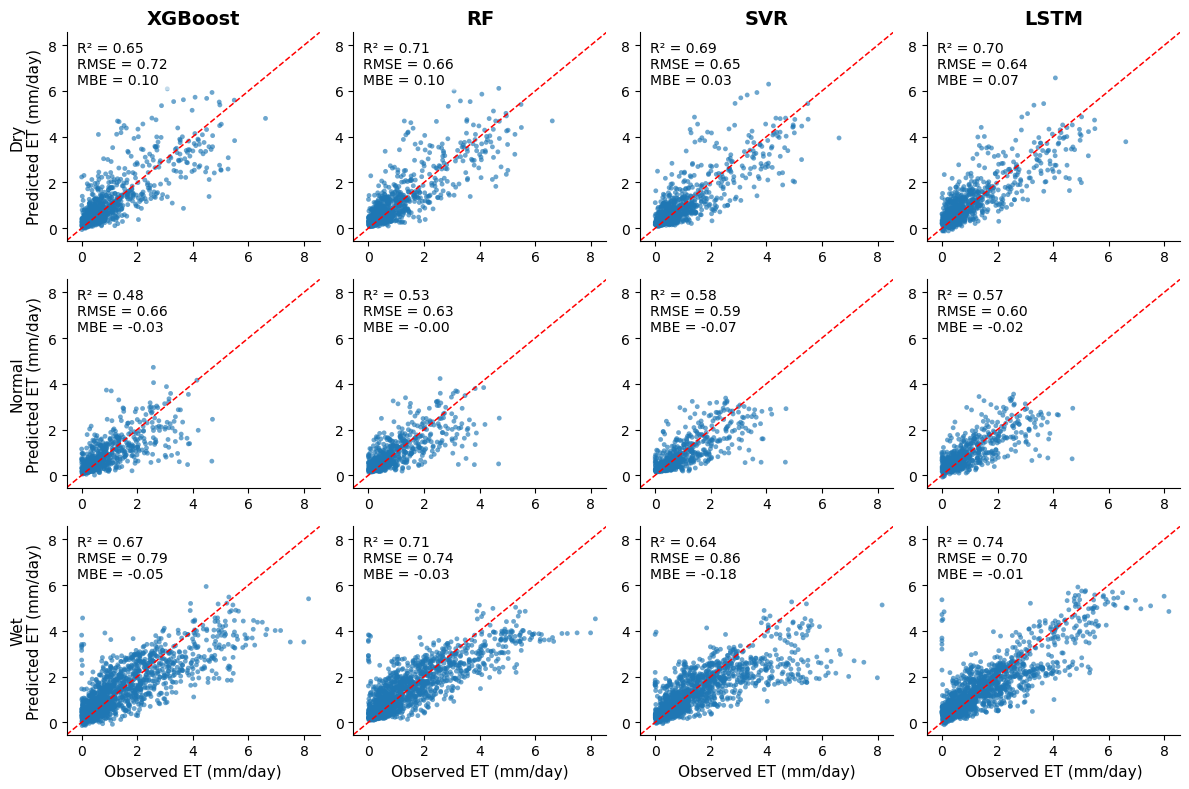

In [8]:
year_groups = {"Dry": [2020, 2022], "Normal": [2019, 2021], "Wet": [2023, 2024, 2025]}

all_vals = pd.concat([p[["y_true", "y_pred"]] for p in loyo_preds.values()]).to_numpy()
lo, hi = all_vals.min() - 0.4, all_vals.max() + 0.4

fig, axes = plt.subplots(3, 4, figsize=(12, 8))
plt.subplots_adjust(hspace=0.40, wspace=0.28)

for r, (group, years) in enumerate(year_groups.items()):
    for c, name in enumerate(MODELS):
        ax = axes[r, c]
        p = loyo_preds[name]
        p = p[p["year"].isin(years)].dropna()
        yt, yp = p["y_true"].to_numpy(), p["y_pred"].to_numpy()

        r2 = np.corrcoef(yt, yp)[0, 1] ** 2 if len(yt) else np.nan
        rmse = np.sqrt(np.mean((yp - yt) ** 2))
        mbe = np.mean(yp - yt)

        ax.scatter(yt, yp, s=12, alpha=0.65, color="#1f77b4", edgecolors="none")
        ax.plot([lo, hi], [lo, hi], "--", color="red", linewidth=1.1)
        ax.text(0.04, 0.96, f"R² = {r2:.2f}\nRMSE = {rmse:.2f}\nMBE = {mbe:.2f}",
                transform=ax.transAxes, fontsize=10, va="top",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.6))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if r == 0:
            ax.set_title(name, fontsize=14, fontweight="bold")
        if c == 0:
            ax.set_ylabel(f"{group}\nPredicted ET (mm/day)", fontsize=11)
        if r == 2:
            ax.set_xlabel("Observed ET (mm/day)", fontsize=11)

plt.tight_layout()
plt.savefig(FIG_DIR / f"loyo_by_year_type_{tag}.png", dpi=300, bbox_inches="tight")
plt.show()

### Observed vs predicted for every held-out year (supplementary)

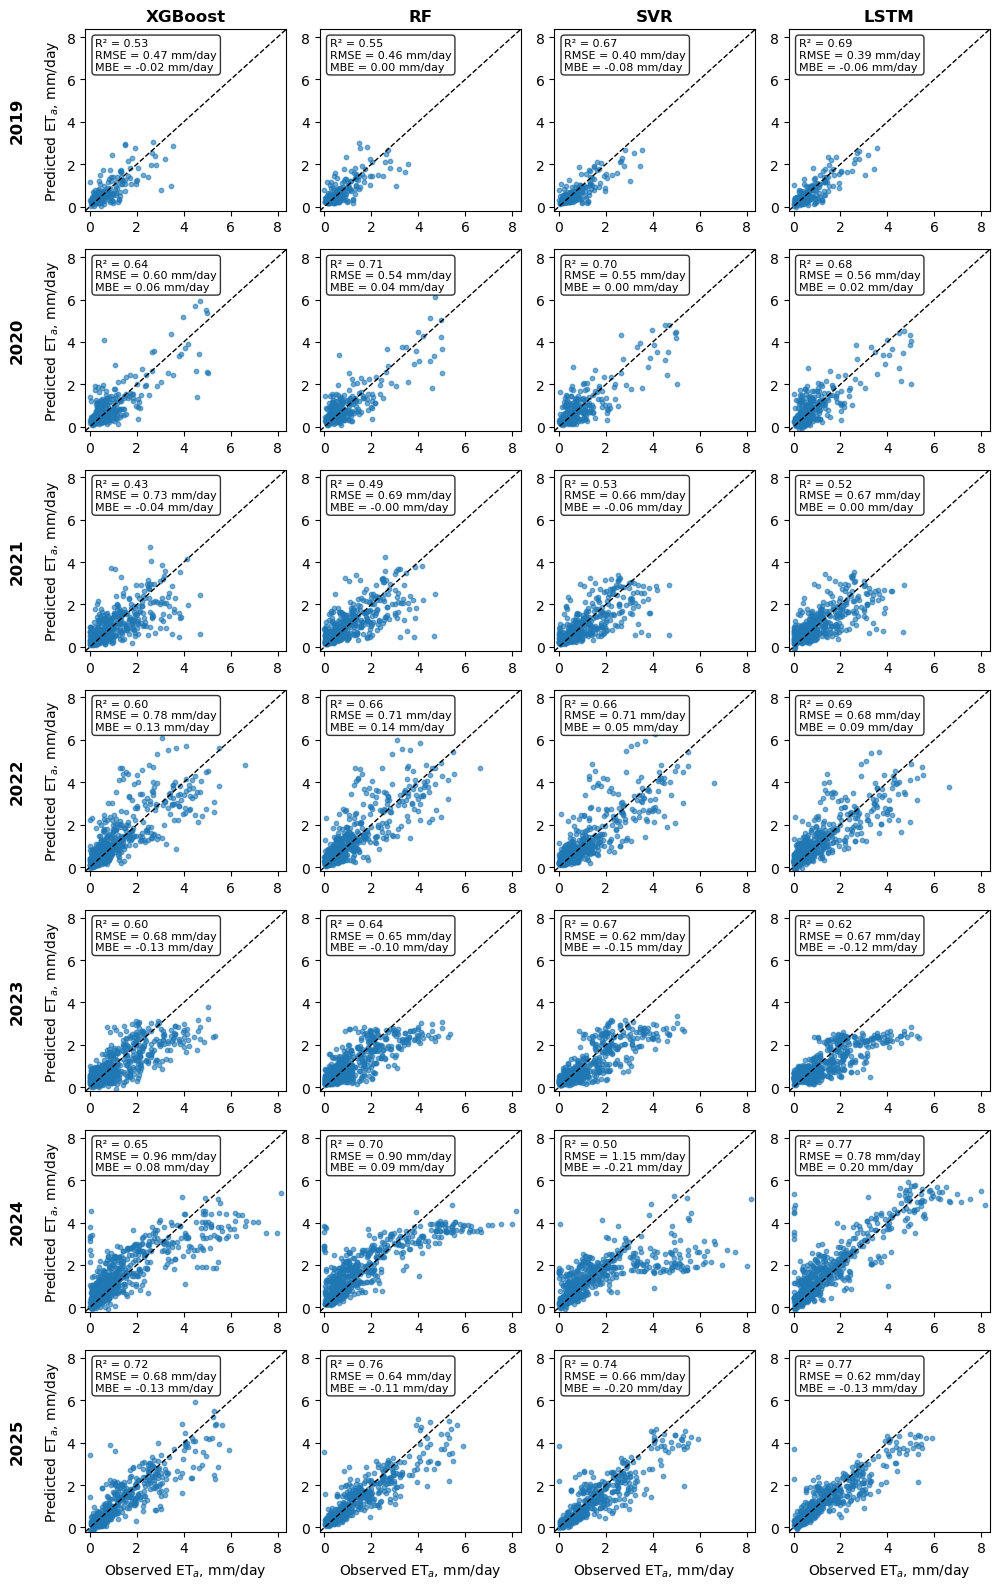

In [9]:
years = sorted(loyo_data["year"].unique())
vmax = max(p[["y_true", "y_pred"]].max().max() for p in loyo_preds.values()) + 0.2
lim = (-0.2, vmax)
ticks = np.arange(0, np.ceil(vmax) + 1, 2)

fig, axes = plt.subplots(len(years), 4, figsize=(10, 16))
for i, year in enumerate(years):
    for j, name in enumerate(MODELS):
        ax = axes[i, j]
        p = loyo_preds[name]
        p = p[p["year"] == year]
        s = loyo_scores[name].set_index("year").loc[year]

        ax.scatter(p["y_true"], p["y_pred"], s=10, alpha=0.6)
        ax.plot(lim, lim, "k--", lw=1)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.text(0.05, 0.95, f"R² = {s.R2:.2f}\nRMSE = {s.RMSE:.2f} mm/day\nMBE = {s.MBE:.2f} mm/day",
                transform=ax.transAxes, fontsize=8, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

        if i == 0:
            ax.set_title(name, fontsize=12, fontweight="bold")
        if i == len(years) - 1:
            ax.set_xlabel("Observed ET$_a$, mm/day", fontsize=10)
        if j == 0:
            ax.set_ylabel("Predicted ET$_a$, mm/day", fontsize=10)
            ax.annotate(str(year), xy=(-0.3, 0.5), xycoords="axes fraction", fontsize=12,
                        ha="right", va="center", rotation=90, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / f"supp_loyo_scatter_by_year_{tag}.png", dpi=300, bbox_inches="tight")
plt.show()

### Distribution of observed and predicted ETa per year

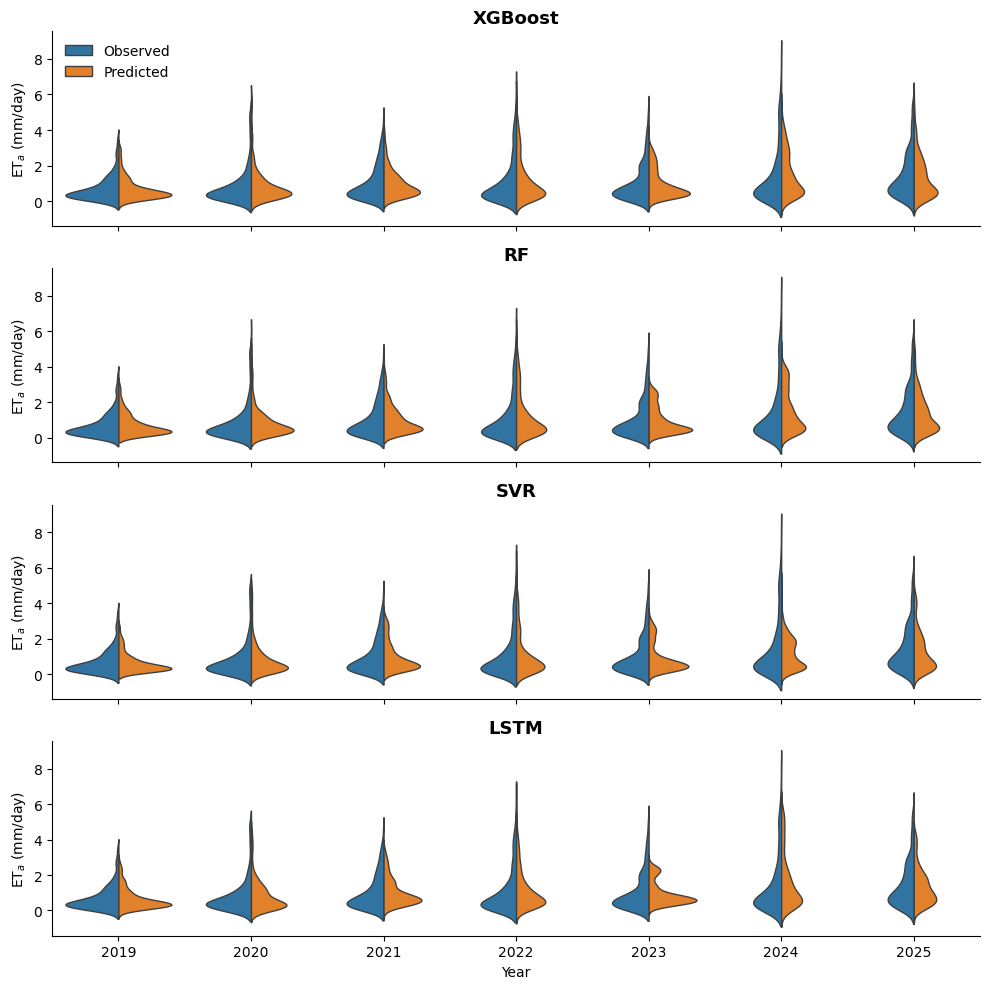

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
for ax, name in zip(axes, MODELS):
    p = loyo_preds[name]
    long = pd.concat([
        pd.DataFrame({"ETa": p["y_true"], "Type": "Observed", "Year": p["year"].astype(str)}),
        pd.DataFrame({"ETa": p["y_pred"], "Type": "Predicted", "Year": p["year"].astype(str)}),
    ])
    sns.violinplot(data=long, x="Year", y="ETa", hue="Type", split=True, inner=None,
                   linewidth=1.0, palette={"Observed": "#1f77b4", "Predicted": "#ff7f0e"}, ax=ax)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_ylabel("ET$_a$ (mm/day)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if name != MODELS[0]:
        ax.get_legend().remove()
    else:
        ax.legend(title="", frameon=False)

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.savefig(FIG_DIR / f"loyo_violin_{tag}.png", dpi=300, bbox_inches="tight")
plt.show()

## Spatial blocking (train on one tower, test on the other)

XGBoost and RF use every row. For SVR and LSTM, rows with any missing value are dropped.

The two transfer directions do not use identical settings for every model: the XGBoost model
trained on BAU uses 500 shallow trees with a small learning rate, and the LSTM batch size is 32 for
ASP -> BAU and 64 for BAU -> ASP. These are the settings behind the published results.

In [11]:
sites = {"ASP": ASP, "BAU": BAU}
sites_complete = {k: v.dropna() for k, v in sites.items()}
directions = [("ASP", "BAU"), ("BAU", "ASP")]        # (train, test)

XGB_PARAMS = {
    "ASP": {},
    "BAU": {"n_estimators": 500, "max_depth": 3, "learning_rate": 0.01, "random_state": 42},
}
LSTM_BATCH = {"ASP": 32, "BAU": 64}


def xgb_site(train, test, train_site):
    m = XGBRegressor(objective="reg:squarederror", **XGB_PARAMS[train_site])
    return m.fit(train[FEATURES], train[TARGET]).predict(test[FEATURES])


def rf_site(train, test, train_site):
    m = RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_split=2,
                              min_samples_leaf=1, random_state=42, n_jobs=-1)
    return m.fit(train[FEATURES], train[TARGET]).predict(test[FEATURES])


def svr_site(train, test, train_site):
    m = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=1.0, epsilon=0.5, gamma="scale"))
    return m.fit(train[FEATURES], train[TARGET]).predict(test[FEATURES])


def lstm_site(train, test, train_site):
    sx, sy = StandardScaler(), StandardScaler()
    X_train = sx.fit_transform(train[FEATURES]).reshape(-1, 1, len(FEATURES))
    X_test = sx.transform(test[FEATURES]).reshape(-1, 1, len(FEATURES))
    y_train = sy.fit_transform(train[[TARGET]])
    model = lstm_model(50)
    model.fit(X_train, y_train, epochs=100, batch_size=LSTM_BATCH[train_site], verbose=0)
    return sy.inverse_transform(model.predict(X_test, verbose=0))

In [12]:
spatial_preds, spatial_rows = {}, []

for name, fn, data in [("XGBoost", xgb_site, sites),
                       ("RF", rf_site, sites),
                       ("SVR", svr_site, sites_complete),
                       ("LSTM", lstm_site, sites_complete)]:
    if name == "LSTM":
        set_seeds(12)
    for train_site, test_site in directions:
        train, test = data[train_site], data[test_site]
        y_true = test[TARGET].to_numpy()
        y_pred = np.ravel(fn(train, test, train_site))
        spatial_preds[(name, test_site)] = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
        spatial_rows.append({"model": name, "train": train_site, "test": test_site,
                             **scores(y_true, y_pred)})

spatial_scores = pd.DataFrame(spatial_rows)
spatial_scores.to_csv(TABLE_DIR / f"spatial_metrics_{tag}.csv", index=False)
spatial_scores.round(3)

,model,train,test,R2,RMSE,MBE
0,XGBoost,ASP,BAU,0.635,0.739,-0.091
1,XGBoost,BAU,ASP,0.707,0.677,0.106
2,RF,ASP,BAU,0.689,0.683,-0.103
3,RF,BAU,ASP,0.713,0.671,0.109
4,SVR,ASP,BAU,0.722,0.647,-0.058
5,SVR,BAU,ASP,0.685,0.698,0.189
6,LSTM,ASP,BAU,0.742,0.623,-0.119
7,LSTM,BAU,ASP,0.706,0.674,0.109


### Observed vs predicted at the unseen tower (Fig. 8 / Fig. 9)

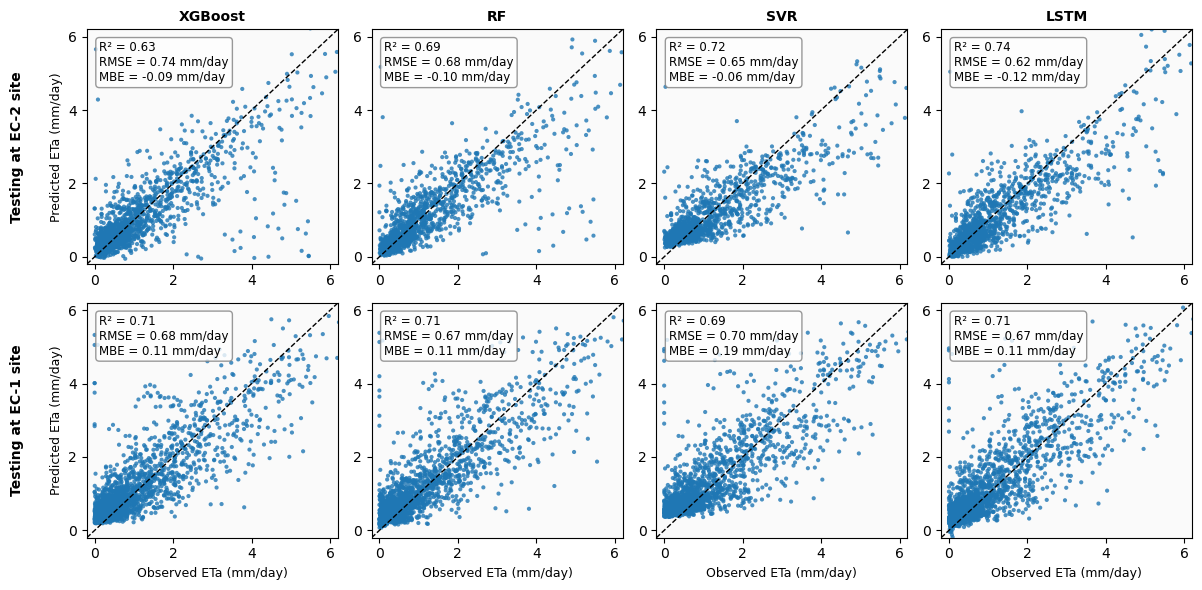

In [13]:
lim, ticks = (-0.2, 6.2), np.arange(0, 7, 2)
row_labels = {"BAU": "Testing at EC-2 site", "ASP": "Testing at EC-1 site"}

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for col, name in enumerate(MODELS):
    for row, test_site in enumerate(["BAU", "ASP"]):
        ax = axes[row, col]
        p = spatial_preds[(name, test_site)]
        s = spatial_scores[(spatial_scores["model"] == name) & (spatial_scores["test"] == test_site)].iloc[0]

        ax.scatter(p["y_true"], p["y_pred"], s=9, alpha=0.8, color="#1f77b4", edgecolors="none")
        ax.plot(lim, lim, "k--", linewidth=1)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_facecolor("#fafafa")
        ax.text(0.05, 0.95, f"R² = {s.R2:.2f}\nRMSE = {s.RMSE:.2f} mm/day\nMBE = {s.MBE:.2f} mm/day",
                transform=ax.transAxes, fontsize=8.5, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))

        if row == 0:
            ax.set_title(name, fontsize=10, fontweight="bold")
        if row == 1:
            ax.set_xlabel("Observed ETa (mm/day)", fontsize=9)
        if col == 0:
            ax.set_ylabel("Predicted ETa (mm/day)", fontsize=9)
            ax.annotate(row_labels[test_site], xy=(-0.25, 0.5), xycoords="axes fraction",
                        fontsize=10, fontweight="bold", va="center", ha="right", rotation=90)

plt.tight_layout()
plt.savefig(FIG_DIR / f"spatial_transfer_{tag}.png", dpi=300, bbox_inches="tight")
plt.show()